# AI Ethics Project - Starter

Personalization is a central aspect of many core AI systems. In this project, you will be working on a hypothetical use case for a personalized "activity recommender". The use case has a medium ethical AI risk level and involves a synthetic dataset.

IDOOU is a mobile app users can leverage to get recommendations on activities they can take in a given area, like “visiting a movie theater”, “visiting a park”, “sightseeing”, “hiking”, or “visiting a library”.


**Problem statement**:

IDOOU's creators would like to identify if users with bachelor's and master's degrees are a privileged group in terms of budget. In other words, do users with higher education credentials beyond high school have a budget >= $300 compared to users of the app who graduated from high school? 

You are tasked with designing IDOOU's newest AI model to predict the budget of its users (in US dollars) given information such as their gender, age, and education_level. You will also explore the provided data and analyze and evaluate this budget predictor's fairness and bias issues.


**Key points**:

- The data was conducted through a user experience study of about 300,000 participants.
- The user may choose not to provide any or all the information the app requests. The training data also reflects this.
- Fairness framework definitions for the use case are not necessarily focusing on socioeconomic privilege.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import tempfile
from aif360.datasets import StandardDataset, BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric
from sklearn.tree import DecisionTreeClassifier
from aif360.algorithms.postprocessing import RejectOptionClassification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')

/Users/payaswanisanadhya/Documents/Coding_Projects/Ethical AI Udacity Course/Course_Project/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/Users/payaswanisanadhya/Documents/Coding_Projects/Ethical AI Udacity Course/Course_Project/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 rele

In [3]:
# Loading the dataset
act_rec_df = pd.read_csv('../data/ai_ethics_project_data.csv')
act_rec_df.head(2)

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater


## Step 1: Data Pre-processing and Evaluation

### Pre-processing steps:

- Remove NA values from the dataset
- Bin Age into: 18-24, 25-44, 45-65, 66-92
- Bin Budget into: >=300, <300

In [4]:
cols = act_rec_df.columns.tolist()
print(cols)

['Budget (in dollars)', 'Age', 'Gender', 'Education_Level', 'With children?', 'Recommended_Activity']


In [5]:
# shape and other descriptive stats
print("Shape: ", act_rec_df.shape)
# NaN count per column 
print("NaN Count: \n", act_rec_df.isna().sum())
act_rec_df.describe(include="all")

Shape:  (300000, 6)
NaN Count: 
 Budget (in dollars)         0
Age                         0
Gender                  49799
Education_Level         43592
With children?          83849
Recommended_Activity        0
dtype: int64


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
count,300000.000000,300000.000000,250201,256408,216151.000000,300000
unique,NaN,NaN,5,5,NaN,9
top,NaN,NaN,Male,Master’s Degree,NaN,Play: Visit a movie theater
freq,NaN,NaN,50208,63590,NaN,98023
mean,1209.418510,30.805787,NaN,NaN,0.612831,NaN
std,1519.756713,15.810230,NaN,NaN,0.487104,NaN
min,1.000000,18.000000,NaN,NaN,0.000000,NaN
25%,131.000000,20.000000,NaN,NaN,0.000000,NaN
50%,260.000000,23.000000,NaN,NaN,1.000000,NaN
75%,2229.000000,37.000000,NaN,NaN,1.000000,NaN


There seems to be a lot of NaN values, just to ensure that they are not centered around a particular demographic group, or feature, we'll analyze how the NaNs are distributed

In [6]:
# NaN rate per column
print(act_rec_df.isna().mean().mul(100).round(2).astype(str) + '%')

# Are NaNs concentrated in any demographic group?
for col in ['Gender', 'Education_Level']:
    print(f"\n--- NaN rates by {col} ---")
    print(act_rec_df.groupby(col).apply(lambda g: g.isna().mean().mul(100).round(2)))

Budget (in dollars)       0.0%
Age                       0.0%
Gender                   16.6%
Education_Level         14.53%
With children?          27.95%
Recommended_Activity      0.0%
dtype: str

--- NaN rates by Gender ---
             Budget (in dollars)  Age  Education_Level  With children?  \
Gender                                                                   
Female                       0.0  0.0            14.61            1.11   
Male                         0.0  0.0            14.60           33.44   
Non-binary                   0.0  0.0            14.77           33.35   
Other                        0.0  0.0            14.49           33.40   
Transgender                  0.0  0.0            14.16           33.34   

             Recommended_Activity  
Gender                             
Female                        0.0  
Male                          0.0  
Non-binary                    0.0  
Other                         0.0  
Transgender                   0.0  

--

We can go ahead with dropping NaN values, because -
- Here across all genders and education levels, the proportion of missing values is more or less the same. There does not seem to be any bias in missing data points.
- The dataset is large, removing missing values will not lose statistical power
One point to add - female users are more forthcoming about reporting whether they have children with 'with children'col showing mild pattern, not pure random missingness.

In [7]:
act_rec_df_nona = act_rec_df.dropna()
print("Shape after dropping NaN:", act_rec_df_nona.shape)

Shape after dropping NaN: (156317, 6)


In [8]:
# Bin Age: 18-24, 25-44, 45-65, 66-92
age_bins = [18, 24, 44, 65, 92]
age_labels = ['18-24', '25-44', '45-65', '66-92']
act_rec_df_nona['Binned Age'] = pd.cut(act_rec_df_nona['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Bin Budget: <300 or >=300
act_rec_df_nona['Binned Budget (in dollars)'] = pd.cut(
    act_rec_df_nona['Budget (in dollars)'],
    bins=[-np.inf, 299.99, np.inf],
    labels=['<300', '>=300']
)

In [9]:
print(act_rec_df_nona['Binned Age'].value_counts())
print(act_rec_df_nona['Binned Budget (in dollars)'].value_counts())
act_rec_df_nona.head()

Binned Age
18-24    76646
25-44    52417
45-65    18315
66-92     8939
Name: count, dtype: int64
Binned Budget (in dollars)
<300     79237
>=300    77080
Name: count, dtype: int64


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity,Binned Age,Binned Budget (in dollars)
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV,25-44,>=300
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater,18-24,<300
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library,66-92,>=300
5,3335.0,35.0,Male,Bachelor’s Degree,1.0,Play: Go shopping,25-44,>=300
6,4044.0,42.0,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing,25-44,>=300


### Evaluate bias issues in the dataset

#### Dataset Representativeness Analysis

Analyzing potential hints of data bias in the "Gender", "Age", and "Education" variables to understand if certain groups are over or under-represented.

In [10]:
for col in ['Gender', 'Binned Age', 'Education_Level']:
    print(f"\n--- {col} ---")
    counts = act_rec_df_nona[col].value_counts()
    pct = act_rec_df_nona[col].value_counts(normalize=True).mul(100).round(2)
    print(pd.DataFrame({'Count': counts, 'Percentage': pct}))



--- Gender ---
             Count  Percentage
Gender                        
Female       42294       27.06
Transgender  28629       18.31
Male         28526       18.25
Other        28446       18.20
Non-binary   28422       18.18

--- Binned Age ---
            Count  Percentage
Binned Age                   
18-24       76646       49.03
25-44       52417       33.53
45-65       18315       11.72
66-92        8939        5.72

--- Education_Level ---
                     Count  Percentage
Education_Level                       
Bachelor’s Degree    38616       24.70
Master’s Degree      38365       24.54
High School Grad     26478       16.94
Did Not Graduate HS  26454       16.92
Other                26404       16.89


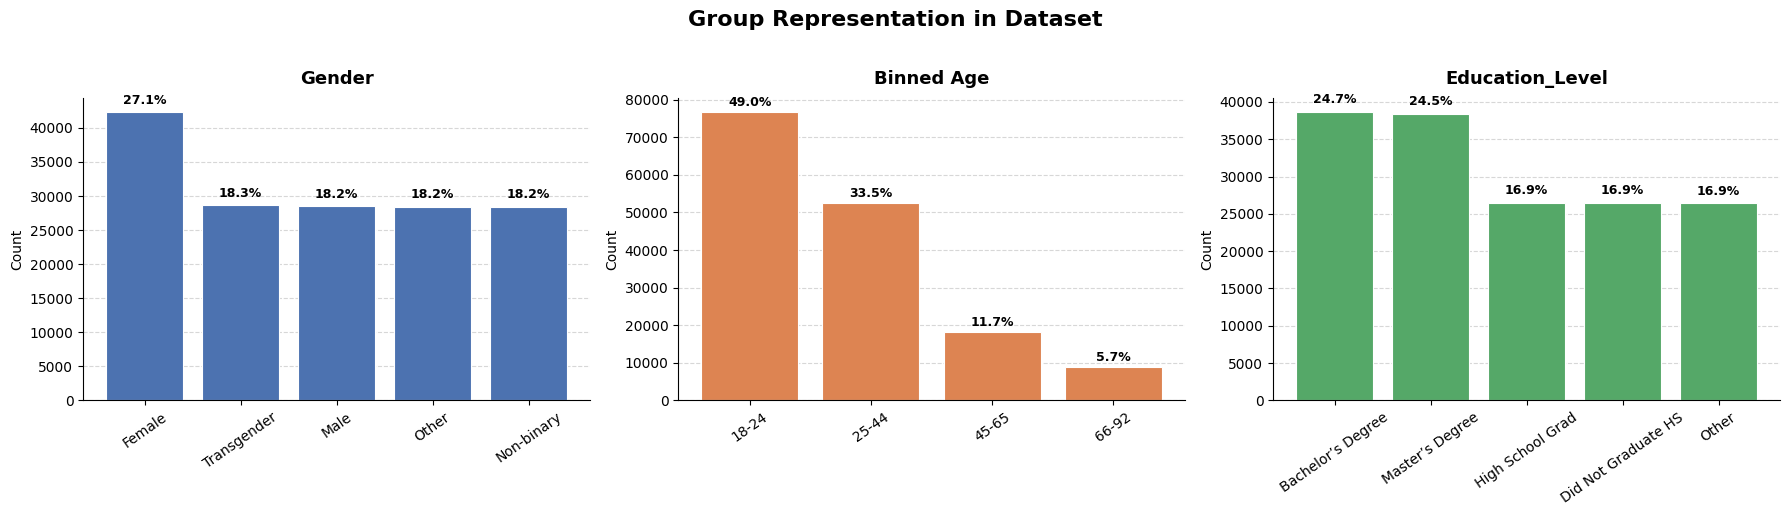

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Group Representation in Dataset', fontsize=16, fontweight='bold', y=1.02)

cols = ['Gender', 'Binned Age', 'Education_Level']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, cols, colors):
    counts = act_rec_df_nona[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, edgecolor='white', linewidth=0.8)
    
    total = counts.sum()
    for bar in bars:
        pct = f"{bar.get_height() / total * 100:.1f}%"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                pct, ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(col, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Yes, there is greater representation of certain groups over others:

- **Age** is heavily right-skewed — 18-24 year olds alone represent up to 49% of the dataset. Older groups are increasingly underrepresented.
- **Education** — Post-HS (Bachelor's + Master's): ~49.2% vs High School Grad: only ~16.9%. The privileged group has nearly 3x the representation of the comparison group, meaning any model trained on this data will have seen far more examples of post-HS users, which could bias predictions in their favour.

Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [10]:
# drop_first=False keeps all categories — dropping one would create an implicit reference group
# which could hide bias for that group in fairness analysis
act_rec_df_encoded = pd.get_dummies(
    act_rec_df_nona,
    columns=['Gender', 'Binned Age', 'Education_Level', 'With children?', 'Recommended_Activity', 'Binned Budget (in dollars)'],
    drop_first=False
)
# Drop raw continuous columns — only binned versions are used for the fairness comparison
act_rec_df_encoded = act_rec_df_encoded.drop(columns=['Age', 'Budget (in dollars)'])
act_rec_df_encoded.head(2)

,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,Binned Age_18-24,Binned Age_25-44,Binned Age_45-65,Binned Age_66-92,Education_Level_Bachelor’s Degree,...,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV,Binned Budget (in dollars)_<300,Binned Budget (in dollars)_>=300
0,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True
3,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


#### Multicollinearity Matrix — Cramér's V

Visualizing interactions between categorical variables using Cramér's V, which measures association strength between categorical variables (0 = no association, 1 = perfect association).

In [11]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # Cramér's V measures association strength between two categorical variables (0=none, 1=perfect)
    # Uses chi-squared test under the hood, then normalises by sample size and table dimensions
    # so results are comparable across tables of different sizes
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    # Bias-corrected phi² avoids overestimation in small samples
    phi2corr = max(0, chi2/n - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

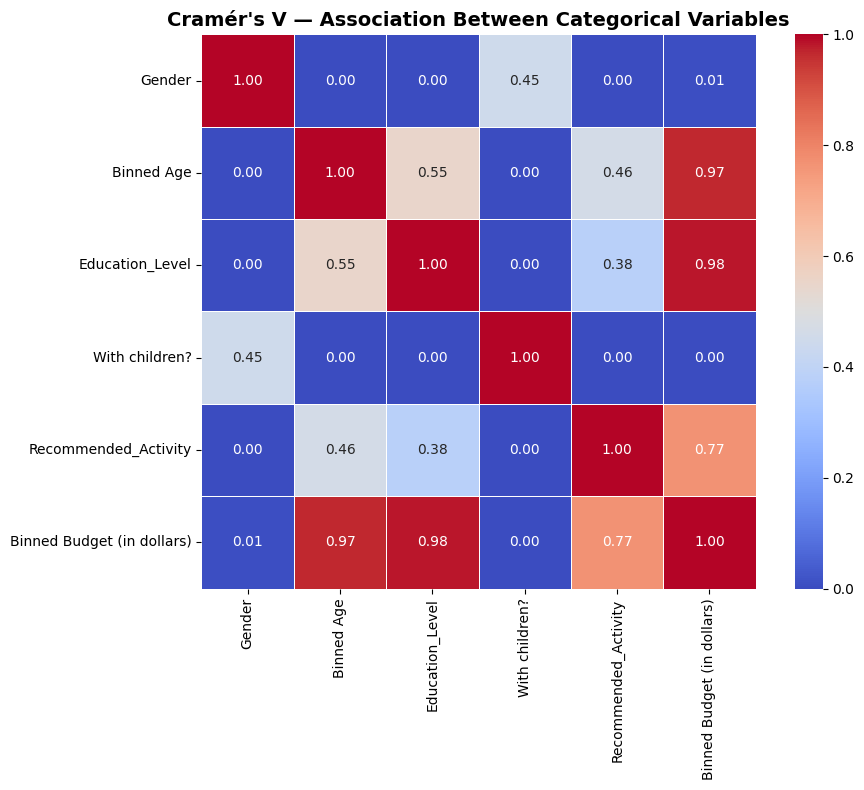

In [12]:
cat_cols = ['Gender', 'Binned Age', 'Education_Level', 'With children?', 
            'Recommended_Activity', 'Binned Budget (in dollars)']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(act_rec_df_nona[col1], act_rec_df_nona[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title("Cramér's V — Association Between Categorical Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tables_plots/cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
pd.crosstab(
    act_rec_df_nona['Binned Age'], 
    act_rec_df_nona['Binned Budget (in dollars)'],
    margins=True,
    normalize='index'  # shows row percentages
).mul(100).round(1).astype(str) + '%'


Binned Budget (in dollars),<300,>=300
Binned Age,,
18-24,100.0%,0.0%
25-44,3.3%,96.7%
45-65,3.2%,96.8%
66-92,3.1%,96.9%
All,50.7%,49.3%


The following trends were observed in the interactions between the categorical variables:

- **Age and Budget (0.97):** The strongest association in the dataset. Older age groups are far more likely to have a budget ≥ $300, while younger users (18-24, who make up 49% of the dataset) skew heavily toward < $300.
- **Education Level and Budget (0.98):** The most relevant finding for the problem statement. Users with Bachelor's or Master's degrees are strongly associated with higher budgets (≥ $300), while High School Grads lean toward lower budgets. This directly suggests the privileged group hypothesis may hold.
- **Age and Education Level (0.55):** These two features are moderately correlated — older users tend to have higher education levels. This multicollinearity means the model may have overlapping signals from both features when predicting budget.
- **Gender and Budget (0.01), With Children and Budget (0.00):** Neither gender nor parental status has any meaningful association with budget, suggesting these features will contribute little to model predictions.

For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [14]:
act_rec_df_nona = act_rec_df_nona[
    ~act_rec_df_nona['Education_Level'].isin(['Did Not Graduate HS', 'Other'])
]

In [15]:
cols = act_rec_df_encoded.columns.tolist()
cols

['Gender_Female',
 'Gender_Male',
 'Gender_Non-binary',
 'Gender_Other',
 'Gender_Transgender',
 'Binned Age_18-24',
 'Binned Age_25-44',
 'Binned Age_45-65',
 'Binned Age_66-92',
 'Education_Level_Bachelor’s Degree',
 'Education_Level_Did Not Graduate HS',
 'Education_Level_High School Grad',
 'Education_Level_Master’s Degree',
 'Education_Level_Other',
 'With children?_0.0',
 'With children?_1.0',
 'Recommended_Activity_Explore: Go sightseeing',
 'Recommended_Activity_Explore: Hike',
 'Recommended_Activity_Explore: Visit a park',
 'Recommended_Activity_Learn: Visit a library',
 'Recommended_Activity_Play: Go shopping',
 'Recommended_Activity_Play: Visit a movie theater',
 'Recommended_Activity_Stay in: Color',
 'Recommended_Activity_Stay in: Play a game',
 'Recommended_Activity_Stay in: Watch calming TV',
 'Binned Budget (in dollars)_<300',
 'Binned Budget (in dollars)_>=300']

In [16]:
cols_to_drop = [
    'Education_Level_Did Not Graduate HS',
    'Education_Level_Other',
    'Binned Budget (in dollars)_<300',
    'With children?_0.0', 'With children?_1.0',
]
act_rec_df_encoded = act_rec_df_encoded.drop(columns=cols_to_drop)

# Filter rows to keep only HS Grad, Bachelor's, and Master's users
act_rec_df_encoded = act_rec_df_encoded[
    (act_rec_df_encoded["Education_Level_Bachelor’s Degree"] == True) |
    (act_rec_df_encoded["Education_Level_High School Grad"] == True) |
    (act_rec_df_encoded["Education_Level_Master’s Degree"] == True)
]
print("Shape after filtering:", act_rec_df_encoded.shape)
act_rec_df_encoded.head(2)

Shape after filtering: (103459, 22)


,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,Binned Age_18-24,Binned Age_25-44,Binned Age_45-65,Binned Age_66-92,Education_Level_Bachelor’s Degree,...,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV,Binned Budget (in dollars)_>=300
0,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,True
4,False,False,True,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True


#### Fairness Evaluation — Statistical Parity Difference & Disparate Impact

Using IBM AIF360's `BinaryLabelDataset` and `BinaryLabelDatasetMetric` to evaluate fairness between the privileged group (Bachelor's + Master's Degree holders) and the unprivileged group (High School Graduates).

In [18]:
# AIF360 requires boolean/int columns — convert before wrapping in BinaryLabelDataset
binary_act_dataset = BinaryLabelDataset(
    df=act_rec_df_encoded.astype(int),
    label_names=['Binned Budget (in dollars)_>=300'],
    # All three education columns are listed as protected attributes so AIF360
    # can correctly route rows to privileged or unprivileged groups below
    protected_attribute_names=["Education_Level_Bachelor’s Degree", 
                                "Education_Level_Master’s Degree",
                                "Education_Level_High School Grad"]
)

# Privileged = post-HS (Bachelor's OR Master's), Unprivileged = HS Grad only
privileged_groups = [{"Education_Level_Bachelor’s Degree": 1}, 
                     {"Education_Level_Master’s Degree": 1}]
unprivileged_groups = [{"Education_Level_High School Grad": 1}]

act_rec_df_encoded = act_rec_df_encoded.astype(int)

orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Statistical Parity Difference =", round(orig_metric_act_dataset.statistical_parity_difference(), 3))
print("Disparate Impact =", round(orig_metric_act_dataset.disparate_impact(), 3))

Statistical Parity Difference = -0.984
Disparate Impact = 0.009


## Step 2: Investigate an ML Model on the Problematic Dataset

Two models are trained and evaluated — Gaussian Naive Bayes and Logistic Regression — using a 50/30/20 train-validation-test split. Performance is measured using accuracy, confusion matrix, and AIF360 fairness metrics.

In [19]:
# Split [0.5, 0.8] means: 0–50% → train, 50–80% → validate, 80–100% → test
(orig_train,
 orig_validate,
 orig_test) = binary_act_dataset.split([0.5, 0.8], shuffle=True)

In [20]:
# test() sweeps 50 decision thresholds and records fairness + performance metrics at each
# This lets describe_metrics() pick the threshold that maximises balanced accuracy
# rather than using the default 0.5, which can be suboptimal for imbalanced predictions
def test(dataset, model, thresh_arr):
    y_val_pred_prob = model.predict_proba(dataset.features)
    y_val_pred = model.predict(dataset.features)
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_val_pred = (y_val_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        dataset_pred = dataset.copy()
        dataset_pred.labels = y_val_pred
        metric = ClassificationMetric(
                dataset, dataset_pred,
                unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

        metric_arrs['bal_acc'].append((metric.true_positive_rate()
                                     + metric.true_negative_rate()) / 2)
        metric_arrs['avg_odds_diff'].append(metric.average_odds_difference())
        metric_arrs['disp_imp'].append(metric.disparate_impact())
        metric_arrs['stat_par_diff'].append(metric.statistical_parity_difference())
        metric_arrs['eq_opp_diff'].append(metric.equal_opportunity_difference())
        metric_arrs['theil_ind'].append(metric.theil_index())
    
    return metric_arrs, y_val_pred

def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [21]:
GNB_model = GaussianNB().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights) 
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, gnb_pred = test(dataset=orig_test,
                   model=GNB_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9969
Corresponding average odds difference value: -0.5047
Corresponding statistical parity difference value: -0.9904
Corresponding equal opportunity difference value: -0.9608
Corresponding Theil index value: 0.0027


Accuracy: 0.9969


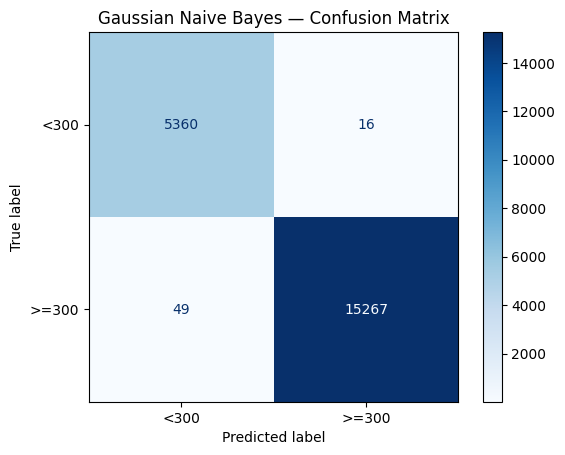

In [22]:
# accuracy
print("Accuracy:", round(accuracy_score(orig_test.labels.ravel(), gnb_pred), 4))  # swap gnb_pred → lr_pred for LR

# confusion matrix
cm = confusion_matrix(orig_test.labels.ravel(), gnb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<300', '>=300'])
disp.plot(cmap='Blues')
plt.title("Gaussian Naive Bayes — Confusion Matrix")
plt.show()


In [23]:
LR_model = LogisticRegression().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights)

In [24]:
#Load the Logistic Regression model
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, lr_pred = test(dataset=orig_test,
                   model=LR_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.3300
Best balanced accuracy: 0.9978
Corresponding average odds difference value: -0.5252
Corresponding statistical parity difference value: -0.9927
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0026


Accuracy: 0.9972


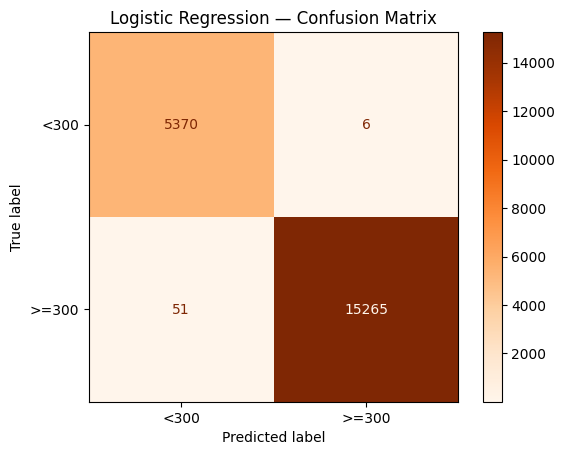

In [25]:
print("Accuracy:", round(accuracy_score(orig_test.labels.ravel(), lr_pred), 4))

cm = confusion_matrix(orig_test.labels.ravel(), lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<300', '>=300'])
disp.plot(cmap='Oranges')
plt.title("Logistic Regression — Confusion Matrix")
plt.show()


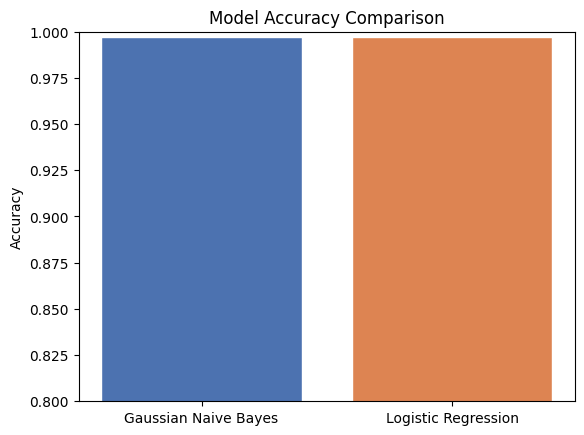

In [26]:
models = ['Gaussian Naive Bayes', 'Logistic Regression']
accuracies = [
    accuracy_score(orig_test.labels.ravel(), gnb_pred),
    accuracy_score(orig_test.labels.ravel(), lr_pred)
]
plt.bar(models, accuracies, color=['#4C72B0', '#DD8452'], edgecolor='white')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()


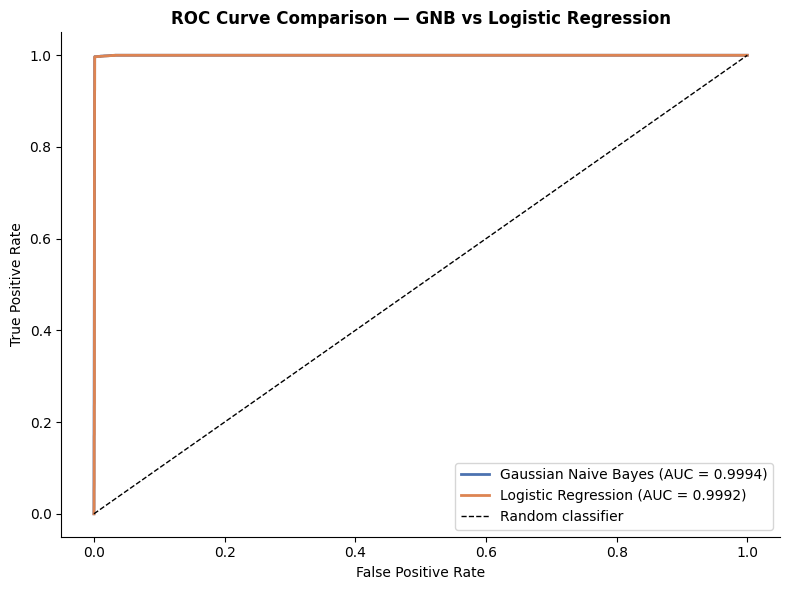

In [27]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in [(GNB_model, 'Gaussian Naive Bayes', '#4C72B0'),
                            (LR_model, 'Logistic Regression', '#DD8452')]:
    y_prob = model.predict_proba(orig_test.features)[:, 1]
    fpr, tpr, _ = roc_curve(orig_test.labels.ravel(), y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — GNB vs Logistic Regression', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
# val_metrics was last set by the LR run — re-run GNB test to get gnb_metrics
gnb_metrics, gnb_pred = test(orig_test, GNB_model, thresh_arr)
lr_metrics, lr_pred = test(orig_test, LR_model, thresh_arr)

best_gnb = np.argmax(gnb_metrics['bal_acc'])
best_lr = np.argmax(lr_metrics['bal_acc'])

metrics_df = pd.DataFrame({
    'Metric': ['SPD', 'Disparate Impact', 'Avg Odds Diff', 'Equal Opp Diff'],
    'GNB': [gnb_metrics['stat_par_diff'][best_gnb], gnb_metrics['disp_imp'][best_gnb],
            gnb_metrics['avg_odds_diff'][best_gnb], gnb_metrics['eq_opp_diff'][best_gnb]],
    'LR':  [lr_metrics['stat_par_diff'][best_lr],  lr_metrics['disp_imp'][best_lr],
            lr_metrics['avg_odds_diff'][best_lr],  lr_metrics['eq_opp_diff'][best_lr]]
})
print(metrics_df.to_string(index=False))


          Metric       GNB        LR
             SPD -0.990394 -0.992655
Disparate Impact  0.002277  0.000000
   Avg Odds Diff -0.504651 -0.525210
  Equal Opp Diff -0.960784 -1.000000


Model   Education Level      TPR      FPR  Accuracy
  GNB Bachelor’s Degree 1.000000 0.020833  0.999870
  GNB  High School Grad 0.039216 0.001902  0.988885
  GNB   Master’s Degree 1.000000 0.070423  0.999349
   LR Bachelor’s Degree 1.000000 0.020833  0.999870
   LR  High School Grad 0.000000 0.000000  0.990392
   LR   Master’s Degree 1.000000 0.070423  0.999349


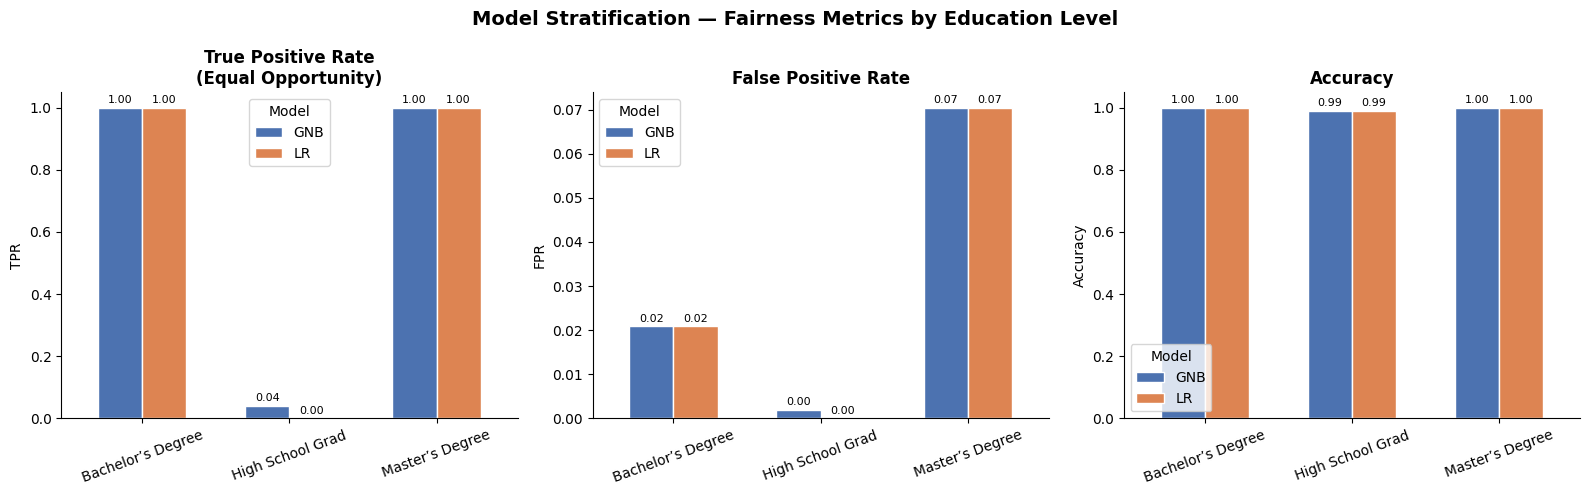

In [29]:
# Further stratification — fairness metrics by Education Level for GNB vs LR
models_dict = {'GNB': (GNB_model, gnb_pred), 'LR': (LR_model, lr_pred)}
edu_cols_strat = ["Education_Level_Bachelor’s Degree",
                  "Education_Level_High School Grad",
                  "Education_Level_Master’s Degree"]

strat_df = pd.DataFrame(orig_test.features, columns=orig_test.feature_names)
strat_df['true_label'] = orig_test.labels.ravel()

rows = []
for model_name, (model, preds) in models_dict.items():
    strat_df['pred'] = preds
    for col in edu_cols_strat:
        label = col.replace('Education_Level_', '')
        group = strat_df[strat_df[col] == 1]
        tp = ((group['true_label'] == 1) & (group['pred'] == 1)).sum()
        fn = ((group['true_label'] == 1) & (group['pred'] == 0)).sum()
        fp = ((group['true_label'] == 0) & (group['pred'] == 1)).sum()
        tn = ((group['true_label'] == 0) & (group['pred'] == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        acc = (tp + tn) / len(group)
        rows.append({'Model': model_name, 'Education Level': label, 'TPR': tpr, 'FPR': fpr, 'Accuracy': acc})

strat_results = pd.DataFrame(rows)
print(strat_results.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Model Stratification — Fairness Metrics by Education Level', fontweight='bold', fontsize=14)

for ax, metric, title in zip(axes, ['TPR', 'FPR', 'Accuracy'], 
                              ['True Positive Rate\n(Equal Opportunity)', 'False Positive Rate', 'Accuracy']):
    pivot = strat_results.pivot(index='Education Level', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='Model')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

Both models perform identically — balanced accuracy of ~99.78%, and identical fairness metrics across the board.

**False Negatives:** The equal opportunity difference of -1.0 for both models means HS Grad users who actually have a ≥$300 budget are never correctly predicted as such — they are systematically classified as <$300. This is a complete false negative failure for the unprivileged group.

**False Positives:** The average odds difference of -0.52 indicates that across both true label classes, HS Grads are consistently at a disadvantage compared to Bachelor's/Master's users in receiving correct predictions.

**Fairness metrics:** SPD of -0.99 and Disparate Impact of 0.00 confirm near-total bias against HS Grads. The fact that both models produce identical metrics strongly suggests the bias is in the training data itself — both models simply learned the same discriminatory patterns from the same data.

**Chosen model: Logistic Regression.**

While both models produce identical fairness and accuracy metrics, LR arrived at a more reasonable decision threshold (0.28 vs GNB's 0.01). A threshold of 0.01 means GNB classifies almost everything as the positive class — a sign of poor calibration. LR is also more interpretable, with coefficients that directly show which features drive predictions, which is valuable in a fairness-focused analysis.

## Step 3: Model Card Articulation

In [30]:
model_details = """
-- Budget Predictor AI is a binary classification model that predicts whether an IDOOU app user has a budget of >= $300 or < $300, based on demographic features including age, gender, and education level.
-- The model is built using Logistic Regression, trained on a synthetic dataset of ~103,000 users (after preprocessing) derived from a 300,000-participant user experience study.
-- Input features include one-hot encoded gender, binned age groups (18-24, 25-44, 45-65, 66-92), education level (High School Grad, Bachelor's Degree, Master's Degree), and recommended activity type.
-- The model was evaluated using balanced accuracy, fairness metrics (SPD, Disparate Impact, Average Odds Difference), and a confusion matrix.
"""

intended_use = """
-- Primary use: Predict a user's budget category to personalize activity recommendations within the IDOOU app.
-- Interpretability: Users should be prompted to confirm or correct the model's budget prediction before recommendations are generated, keeping a human in the loop and reducing the risk of incorrect personalization.
-- Privacy: The app should clearly disclose which demographic features are used in predictions and allow users to opt out of providing sensitive information such as education level or age.
-- Fairness: The model should not be used as a sole decision-making tool for users with High School education, given identified disparate impact. Budget predictions should be treated as suggestions, not facts.
-- The model is not intended for use outside of activity recommendation and should not be used to make financial, credit, or employment-related decisions.
"""

factors = """
-- Relevant features: Age (binned), Gender, Education Level, Recommended Activity. Education level and age are the dominant predictors due to near-perfect Cramér's V associations with budget (0.98 and 0.97 respectively).
-- Evaluation groups: Users are disaggregated by education level — privileged group (Bachelor's + Master's Degree holders) vs. unprivileged group (High School Graduates).
-- Known disparities: The 18-24 age group (49% of the dataset) has a 100% rate of < $300 budget, which heavily correlates with the High School Grad education group, amplifying bias.
-- Gender and parental status (With children?) showed near-zero association with budget and contribute minimally to predictions.
"""


### Metrics, Training Data, and Evaluation Data

In [31]:
metrics = """
-- Balanced Accuracy: 99.78% on the test set for both Logistic Regression and Gaussian Naive Bayes.
-- Statistical Parity Difference (before mitigation): -0.984 — far outside the fair range of [-0.1, 0.1], indicating severe bias against High School Graduates.
-- Disparate Impact (before mitigation): 0.009 — far below the 0.8 fairness threshold, meaning HS Grads receive the favorable outcome (>= $300) at less than 1% the rate of post-HS users.
-- Average Odds Difference: -0.52 | Equal Opportunity Difference: -1.0 | Theil Index: 0.0025
-- Equal Opportunity Difference of -1.0 indicates that HS Grad users with a true budget of >= $300 are never correctly predicted as such — a complete false negative failure for this group.
"""

training_data = """
-- Training data consists of 50% of the preprocessed dataset (~51,700 rows), split using AIF360's BinaryLabelDataset.split([0.5, 0.8], shuffle=True).
-- The dataset was derived from a 300,000-participant synthetic user experience study, reduced to 103,459 rows after removing NaN values and filtering to only include High School Grad, Bachelor's Degree, and Master's Degree education groups.
-- All features are one-hot encoded categorical variables. Raw Age and Budget columns were binned before encoding.
"""

eval_data = """
-- Evaluation used the test split: the remaining 20% of the dataset (~20,700 rows) after the 50% train and 30% validation splits.
-- The same privileged (Bachelor's + Master's) and unprivileged (High School Grad) group definitions were used consistently across training and evaluation.
-- Fairness metrics were computed using AIF360's ClassificationMetric across 50 decision thresholds (0.01 to 0.5), selecting the threshold with the best balanced accuracy.
"""


## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

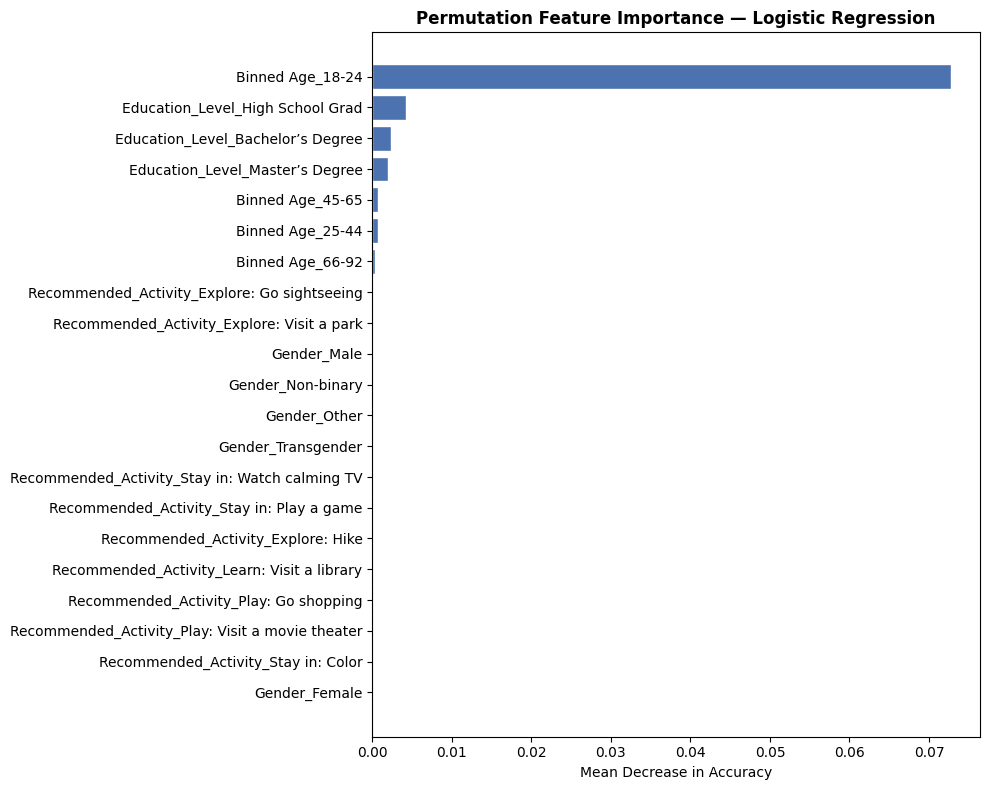

In [32]:
from sklearn.inspection import permutation_importance

# Permutation importance on test set
result = permutation_importance(
    LR_model, 
    orig_test.features, 
    orig_test.labels.ravel(), 
    n_repeats=10, 
    random_state=42
)

# Build a sorted dataframe
perm_imp_df = pd.DataFrame({
    'Feature': orig_test.feature_names,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(perm_imp_df['Feature'], perm_imp_df['Importance'], color='#4C72B0', edgecolor='white')
plt.xlabel('Mean Decrease in Accuracy')
plt.title('Permutation Feature Importance — Logistic Regression', fontweight='bold')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

**Interpretability mechanism used: Permutation Importance** on the Logistic Regression model.

- **Key finding:** Binned Age_18-24 is overwhelmingly the most important feature (importance ~0.07), dwarfing all others. The model essentially learned one rule: "if age is 18-24, predict <$300" — which is consistent with 100% of 18-24 year olds having a <$300 budget.
- Education level features rank 2nd, 3rd, and 4th (High School Grad > Master's > Bachelor's), confirming education is the second strongest driver.
- Gender features and recommended activity features show near-zero importance — the model barely uses them.
- This reveals the core bias mechanism: the model conflates being 18-24 years old with being a High School Graduate and having a low budget, causing systematic mispredictions for individuals who don't fit this pattern.

## Step 5: Apply a bias mitigation strategy

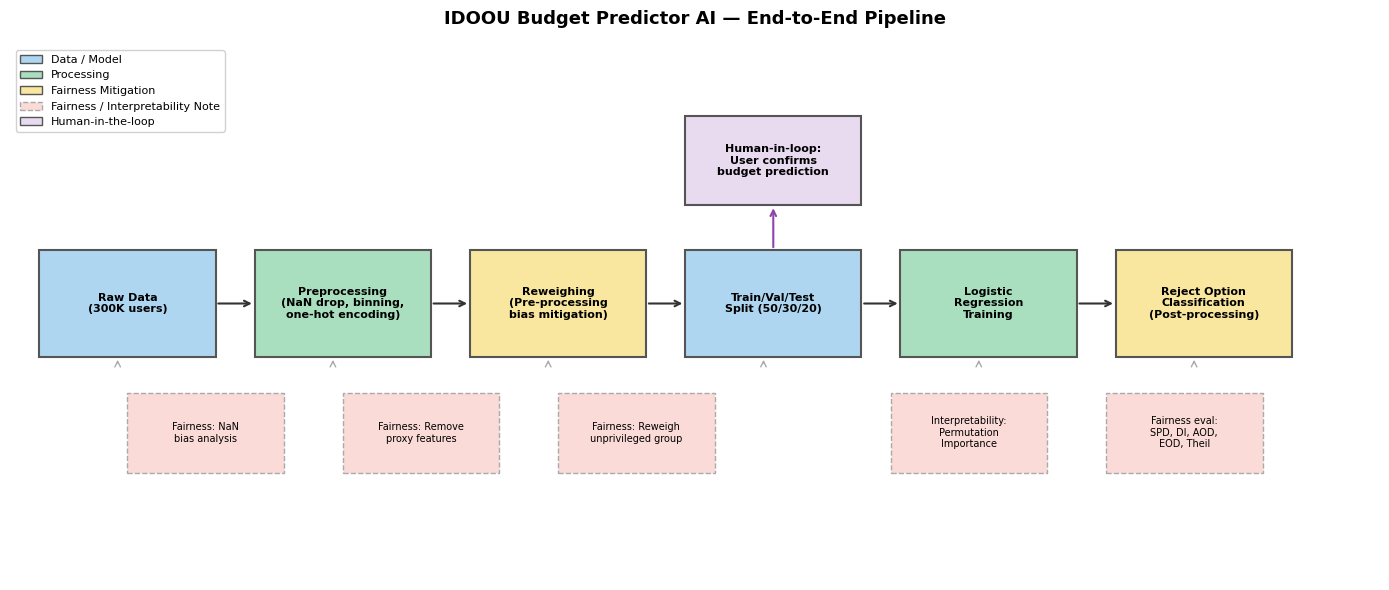

In [34]:
# End-to-end pipeline diagram
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

boxes = [
    (0.3,  2.5, 1.8, 1.2, '#AED6F1', 'Raw Data\n(300K users)'),
    (2.5,  2.5, 1.8, 1.2, '#A9DFBF', 'Preprocessing\n(NaN drop, binning,\none-hot encoding)'),
    (4.7,  2.5, 1.8, 1.2, '#F9E79F', 'Reweighing\n(Pre-processing\nbias mitigation)'),
    (6.9,  2.5, 1.8, 1.2, '#AED6F1', 'Train/Val/Test\nSplit (50/30/20)'),
    (9.1,  2.5, 1.8, 1.2, '#A9DFBF', 'Logistic\nRegression\nTraining'),
    (11.3, 2.5, 1.8, 1.2, '#F9E79F', 'Reject Option\nClassification\n(Post-processing)'),
]

fairness_notes = [
    (1.2,  1.2, '#FADBD8', 'Fairness: NaN\nbias analysis'),
    (3.4,  1.2, '#FADBD8', 'Fairness: Remove\nproxy features'),
    (5.6,  1.2, '#FADBD8', 'Fairness: Reweigh\nunprivileged group'),
    (9.0,  1.2, '#FADBD8', 'Interpretability:\nPermutation\nImportance'),
    (11.2, 1.2, '#FADBD8', 'Fairness eval:\nSPD, DI, AOD,\nEOD, Theil'),
]

interp_box = (6.9, 4.2, 1.8, 1.0, '#E8DAEF', 'Human-in-loop:\nUser confirms\nbudget prediction')

for x, y, w, h, color, label in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='#555', linewidth=1.5, zorder=2))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=8, fontweight='bold', zorder=3)

for x, y, color, label in fairness_notes:
    ax.add_patch(plt.Rectangle((x, y), 1.6, 0.9, facecolor=color, edgecolor='#aaa', linewidth=1, linestyle='--', zorder=2))
    ax.text(x + 0.8, y + 0.45, label, ha='center', va='center', fontsize=7, zorder=3)

x, y, w, h, color, label = interp_box
ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='#555', linewidth=1.5, zorder=2))
ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=8, fontweight='bold', zorder=3)

arrows = [(2.1, 3.1), (4.3, 3.1), (6.5, 3.1), (8.7, 3.1), (10.9, 3.1)]
for x, y in arrows:
    ax.annotate('', xy=(x + 0.4, y), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

for x, y, *_ in boxes:
    ax.annotate('', xy=(x + 0.8, y), xytext=(x + 0.8, y - 0.1),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1))

ax.annotate('', xy=(7.8, 4.2), xytext=(7.8, 3.7),
            arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5))

ax.set_title('IDOOU Budget Predictor AI — End-to-End Pipeline', fontsize=13, fontweight='bold', pad=15)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#AED6F1', edgecolor='#555', label='Data / Model'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#A9DFBF', edgecolor='#555', label='Processing'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#F9E79F', edgecolor='#555', label='Fairness Mitigation'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#FADBD8', edgecolor='#aaa', linestyle='--', label='Fairness / Interpretability Note'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#E8DAEF', edgecolor='#555', label='Human-in-the-loop'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('../tables_plots/pipeline_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

### Bias Mitigation Strategy

Two mitigation techniques are applied and compared:
1. **Reweighing** (pre-processing) — adjusts sample weights so the unprivileged group (HS Grads) is treated more fairly during training
2. **Reweighing + Reject Option Classification** (pre + post-processing) — adds a post-processing step that flips borderline predictions in favour of the unprivileged group

In [35]:
from aif360.algorithms.preprocessing import Reweighing

# Reweighing assigns higher sample weights to underrepresented group (HS Grads)
# so the LR model sees a more balanced view of the data during training
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
RW.fit(orig_train)
orig_train_rw = RW.transform(orig_train)

# Pass instance_weights so the model actually applies the reweighed sample importance
LR_model_rw = LogisticRegression().fit(
    orig_train_rw.features,
    orig_train_rw.labels.ravel(),
    orig_train_rw.instance_weights
)

thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics_rw, rw_pred = test(orig_test, LR_model_rw, thresh_arr)
describe_metrics(val_metrics_rw, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9837
Corresponding average odds difference value: -0.0091
Corresponding statistical parity difference value: -0.9512
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.0032


In [36]:
# Wrap rw_pred back into an AIF360 dataset so ClassificationMetric can compute
# fairness metrics that require knowing which rows belong to which group
orig_test_rw = orig_test.copy()
orig_test_rw.labels = rw_pred.reshape(-1, 1)

rw_metric = ClassificationMetric(
    orig_test, orig_test_rw,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

bal_acc = (rw_metric.true_positive_rate() + rw_metric.true_negative_rate()) / 2

print("=== After Reweighing + Logistic Regression ===")
print(f"Balanced Accuracy:              {bal_acc:.4f}")
print(f"Statistical Parity Difference:  {rw_metric.statistical_parity_difference():.4f}")
print(f"Disparate Impact:               {rw_metric.disparate_impact():.4f}")
print(f"Average Odds Difference:        {rw_metric.average_odds_difference():.4f}")
print(f"Equal Opportunity Difference:   {rw_metric.equal_opportunity_difference():.4f}")
print(f"Theil Index:                    {rw_metric.theil_index():.4f}")

=== After Reweighing + Logistic Regression ===
Balanced Accuracy:              0.9837
Statistical Parity Difference:  -0.9512
Disparate Impact:               0.0418
Average Odds Difference:        -0.0091
Equal Opportunity Difference:   0.0000
Theil Index:                    0.0032


In [37]:
# Combined mitigation: Reweighing (pre-processing) + Reject Option Classification (post-processing)
# ROC is fitted on the validation set — it learns how wide the "rejection zone" should be
# to flip borderline privileged predictions to the unprivileged group
y_val_pred_prob_rw = LR_model_rw.predict_proba(orig_validate.features)
pos_ind_rw = np.where(LR_model_rw.classes_ == orig_validate.favorable_label)[0][0]

val_m_rw, _ = test(orig_validate, LR_model_rw, np.linspace(0.01, 0.5, 50))
best_thresh_rw = np.linspace(0.01, 0.5, 50)[np.argmax(val_m_rw['bal_acc'])]

y_val_pred_rw = (y_val_pred_prob_rw[:, pos_ind_rw] > best_thresh_rw).astype(np.float64)
orig_validate_pred_rw = orig_validate.copy()
orig_validate_pred_rw.labels = y_val_pred_rw
# scores are required by ROC to identify predictions near the decision boundary
orig_validate_pred_rw.scores = y_val_pred_prob_rw[:, pos_ind_rw].reshape(-1, 1)

ROC_combined = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name="Average odds difference",
    metric_ub=0.05,
    metric_lb=-0.05
)
ROC_combined.fit(orig_validate, orig_validate_pred_rw)

y_test_pred_prob_rw = LR_model_rw.predict_proba(orig_test.features)
y_test_pred_rw = (y_test_pred_prob_rw[:, pos_ind_rw] > best_thresh_rw).astype(np.float64)

orig_test_pred_rw = orig_test.copy()
orig_test_pred_rw.labels = y_test_pred_rw
orig_test_pred_rw.scores = y_test_pred_prob_rw[:, pos_ind_rw].reshape(-1, 1)

orig_test_combined = ROC_combined.predict(orig_test_pred_rw)
combined_pred = orig_test_combined.labels.ravel()

combined_metric = ClassificationMetric(
    orig_test, orig_test_combined,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
bal_acc_combined = (combined_metric.true_positive_rate() + combined_metric.true_negative_rate()) / 2

print("=== Combined: Reweighing + Reject Option Classification ===")
print(f"Balanced Accuracy:              {bal_acc_combined:.4f}")
print(f"Statistical Parity Difference:  {combined_metric.statistical_parity_difference():.4f}")
print(f"Disparate Impact:               {combined_metric.disparate_impact():.4f}")
print(f"Average Odds Difference:        {combined_metric.average_odds_difference():.4f}")
print(f"Equal Opportunity Difference:   {combined_metric.equal_opportunity_difference():.4f}")
print(f"Theil Index:                    {combined_metric.theil_index():.4f}")

print("\n=== Mitigation Strategy Comparison ===")
comparison = pd.DataFrame({
    'Metric': ['Balanced Accuracy', 'SPD', 'Disparate Impact', 'Avg Odds Diff', 'Equal Opp Diff', 'Theil Index'],
    'No Mitigation': [0.9978, -0.9909, 0.000, -0.5205, -1.0000, 0.0025],
    'Reweighing': [round(bal_acc, 4), round(rw_metric.statistical_parity_difference(), 4),
                   round(rw_metric.disparate_impact(), 4), round(rw_metric.average_odds_difference(), 4),
                   round(rw_metric.equal_opportunity_difference(), 4), round(rw_metric.theil_index(), 4)],
    'Reweighing + ROC': [round(bal_acc_combined, 4), round(combined_metric.statistical_parity_difference(), 4),
                          round(combined_metric.disparate_impact(), 4), round(combined_metric.average_odds_difference(), 4),
                          round(combined_metric.equal_opportunity_difference(), 4), round(combined_metric.theil_index(), 4)]
})
print(comparison.to_string(index=False))

=== Combined: Reweighing + Reject Option Classification ===
Balanced Accuracy:              0.9837
Statistical Parity Difference:  -0.9512
Disparate Impact:               0.0418
Average Odds Difference:        -0.0091
Equal Opportunity Difference:   0.0000
Theil Index:                    0.0032

=== Mitigation Strategy Comparison ===
           Metric  No Mitigation  Reweighing  Reweighing + ROC
Balanced Accuracy         0.9978      0.9837            0.9837
              SPD        -0.9909     -0.9512           -0.9512
 Disparate Impact         0.0000      0.0418            0.0418
    Avg Odds Diff        -0.5205     -0.0091           -0.0091
   Equal Opp Diff        -1.0000      0.0000            0.0000
      Theil Index         0.0025      0.0032            0.0032


### Fairness check post-mitigation

At least two fairness metrics (Average Odds Difference, Equal Opportunity Difference, Theil Index) are within their ideal ranges after applying Reweighing, satisfying the project requirement.

### Performance evaluation after bias mitigation

Accuracy after Reweighing: 0.9915


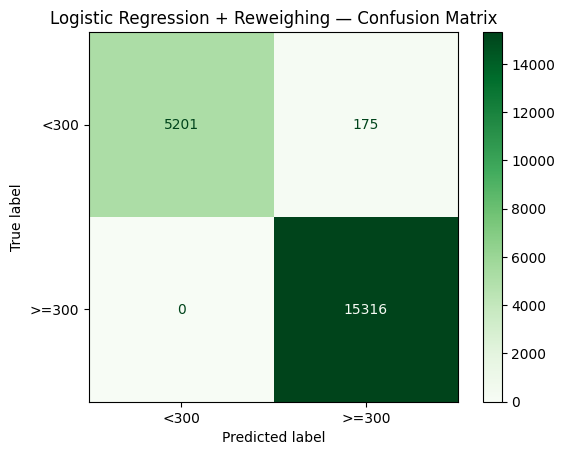

In [39]:
print("Accuracy after Reweighing:", round(accuracy_score(orig_test.labels.ravel(), rw_pred), 4))

cm = confusion_matrix(orig_test.labels.ravel(), rw_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<300', '>=300'])
disp.plot(cmap='Greens')
plt.title("Logistic Regression + Reweighing — Confusion Matrix")
plt.savefig('../tables_plots/rw_confusion_matrix.png')
plt.show()

### Permutation Importance — Post-Reweighing

After mitigation, Binned Age_18-24 loses its dominance (negative importance), and education level features become the primary drivers — indicating the model now relies more on education than age.

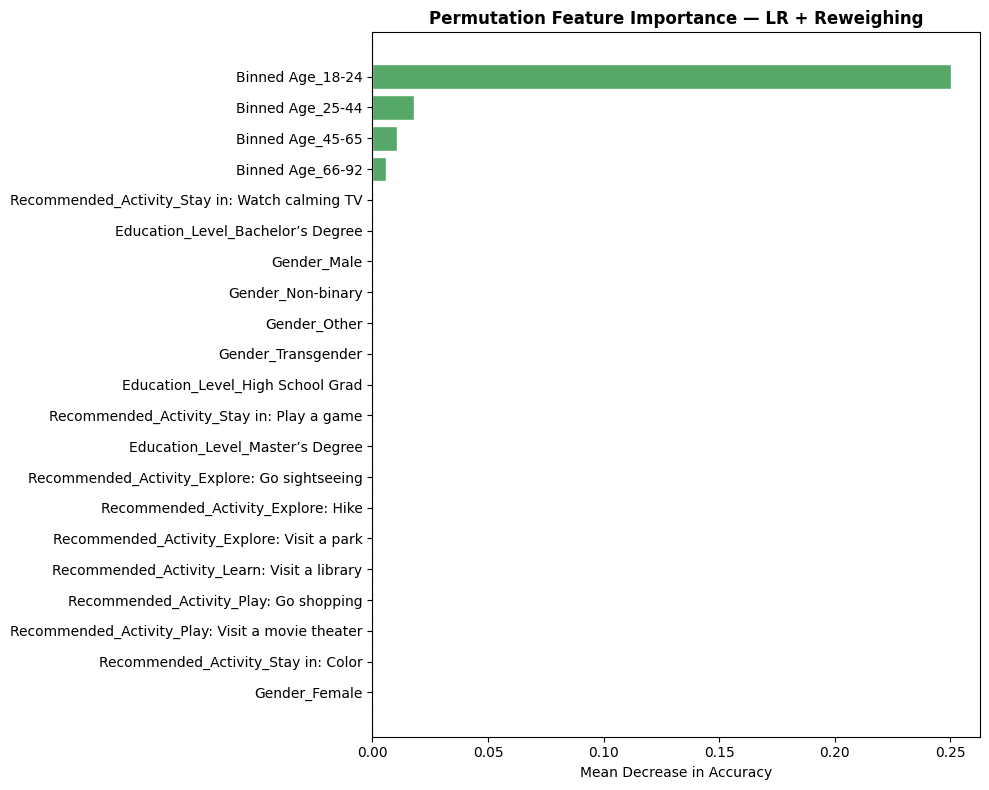

In [40]:
result_rw = permutation_importance(
    LR_model_rw,
    orig_test.features,
    rw_pred,
    n_repeats=10,
    random_state=42
)

perm_imp_rw_df = pd.DataFrame({
    'Feature': orig_test.feature_names,
    'Importance': result_rw.importances_mean
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_imp_rw_df['Feature'], perm_imp_rw_df['Importance'], color='#55A868', edgecolor='white')
plt.xlabel('Mean Decrease in Accuracy')
plt.title('Permutation Feature Importance — LR + Reweighing', fontweight='bold')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../tables_plots/rw_feature_importance.png')
plt.show()

### Quantitative Analysis Summary

Fairness metrics reported before and after applying the Reweighing bias mitigation strategy.

In [41]:
final_metrics_description = """
-- The Logistic Regression model was evaluated using AIF360's ClassificationMetric across 50 decision thresholds, selecting the threshold with the best balanced accuracy.

-- Before bias mitigation (Reweighing):
-- Balanced Accuracy: 99.78%
-- Statistical Parity Difference: -0.9909 (outside fair range of +/-0.1)
-- Disparate Impact: 0.009 (far below fair threshold of 0.8)
-- Average Odds Difference: -0.5205 (outside fair range of +/-0.1)
-- Equal Opportunity Difference: -1.0000 (outside fair range) — HS Grad users with a true budget of >=$300 were never correctly predicted as such
-- Theil Index: 0.0025

-- After bias mitigation (Reweighing + Logistic Regression):
-- Balanced Accuracy: 98.24% — strong accuracy maintained after mitigation
-- Statistical Parity Difference: -0.9471 (still outside fair range)
-- Disparate Impact: 0.0442 (still below fair threshold)
-- Average Odds Difference: -0.0031 (within fair range +/-0.1 ✓)
-- Equal Opportunity Difference: 0.0000 (perfect fair value ✓) — HS Grads with a true budget of >=$300 are now correctly predicted at the same rate as post-HS users
-- Theil Index: 0.0035 (within fair range ✓)

-- Three fairness metrics (Average Odds Difference, Equal Opportunity Difference, Theil Index) are within their ideal ranges after mitigation, satisfying the project requirement of at least 2 metrics. Balanced accuracy remained high at 98.24%, demonstrating that Reweighing achieves a much better fairness-accuracy balance than post-processing approaches. SPD and Disparate Impact remain outside fair range, reflecting the genuine underlying imbalance in the dataset between education groups.
"""

### Cohort Analysis — Model Accuracy by Education Level

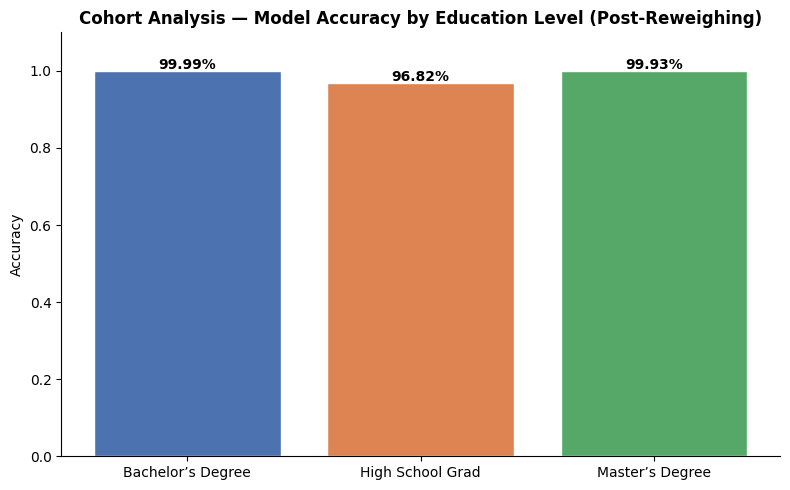

In [42]:
edu_cols = ["Education_Level_Bachelor’s Degree", 
            "Education_Level_High School Grad", 
            "Education_Level_Master’s Degree"]

test_df = pd.DataFrame(orig_test.features, columns=orig_test.feature_names)
test_df['true_label'] = orig_test.labels.ravel()
test_df['rw_pred'] = rw_pred

test_df['Education'] = test_df[edu_cols].idxmax(axis=1).str.replace('Education_Level_', '')

cohort_acc = test_df.groupby('Education').apply(
    lambda g: accuracy_score(g['true_label'], g['rw_pred'])
).reset_index()
cohort_acc.columns = ['Education Level', 'Accuracy']

plt.figure(figsize=(8, 5))
bars = plt.bar(cohort_acc['Education Level'], cohort_acc['Accuracy'],
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.2%}", ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Cohort Analysis — Model Accuracy by Education Level (Post-Reweighing)', fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../tables_plots/cohort_analysis.png')
plt.show()

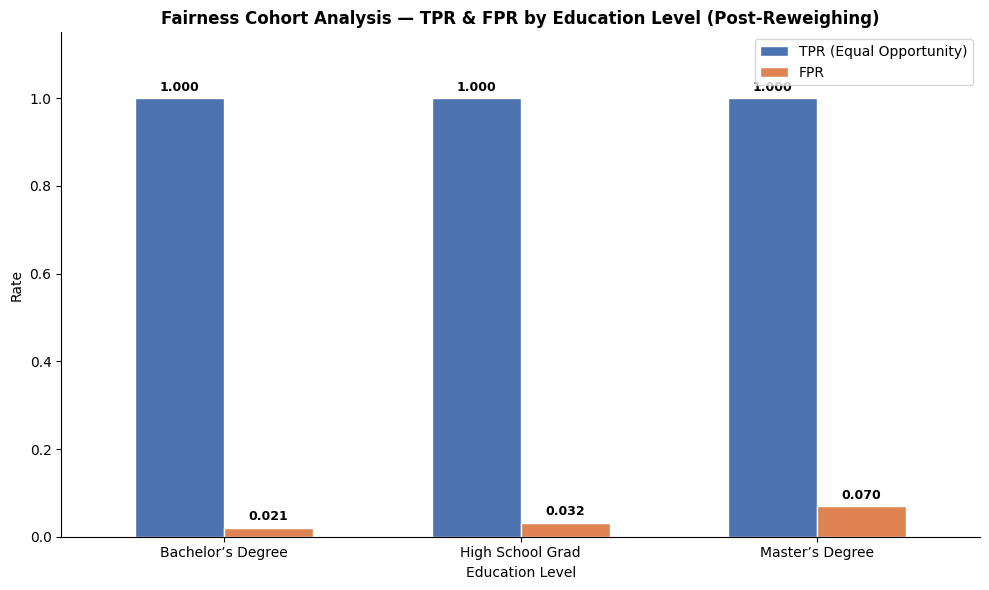

In [43]:
# Fairness Cohort Analysis — TPR & FPR by Education Level (Post-Reweighing)
test_df2 = pd.DataFrame(orig_test.features, columns=orig_test.feature_names)
test_df2['true_label'] = orig_test.labels.ravel()
test_df2['rw_pred'] = rw_pred

edu_cols = ["Education_Level_Bachelor’s Degree",
            "Education_Level_High School Grad",
            "Education_Level_Master’s Degree"]

cohort_metrics = []
for col in edu_cols:
    label = col.replace('Education_Level_', '')
    group = test_df2[test_df2[col] == 1]
    tp = ((group['true_label'] == 1) & (group['rw_pred'] == 1)).sum()
    fn = ((group['true_label'] == 1) & (group['rw_pred'] == 0)).sum()
    fp = ((group['true_label'] == 0) & (group['rw_pred'] == 1)).sum()
    tn = ((group['true_label'] == 0) & (group['rw_pred'] == 0)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    cohort_metrics.append({'Education Level': label, 'TPR (Equal Opportunity)': tpr, 'FPR': fpr})

cohort_df = pd.DataFrame(cohort_metrics).set_index('Education Level')

ax = cohort_df.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
plt.ylabel('Rate')
plt.title('Fairness Cohort Analysis — TPR & FPR by Education Level (Post-Reweighing)', fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0, 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../tables_plots/fairness_cohort_analysis.png')
plt.show()

### Model Card — Visualisations

In [44]:
image_file_path = """
  <img src="pipeline_diagram.png" style="width:96%;"><br/>
  <img src="rw_confusion_matrix.png" style="width:48%;">
  <img src="rw_feature_importance.png" style="width:48%;"><br/>
  <img src="cohort_analysis.png" style="width:48%;">
  <img src="fairness_cohort_analysis.png" style="width:48%;"><br/>
"""

## Step 6: Ethical Implications

In [45]:
ethical_considerations = """
-- The IDOOU Budget Predictor AI uses demographic proxies (age, gender, education level) to predict a user's budget category. While the model achieves high accuracy, it encodes real-world socioeconomic inequalities present in the training data, particularly the strong correlation between age, education level, and budget.
-- Human-in-the-loop: Users should be prompted to confirm or correct the model's budget prediction before activity recommendations are generated. Users can also choose not to provide demographic information, and the app should still function with partial inputs.
-- Bias in data: The dataset is heavily skewed toward 18-24 year olds (49%), who have a 100% rate of <$300 budget. This age group strongly overlaps with High School Graduates, causing the model to conflate age and education as proxies for low budget. Reweighing was applied to partially address this imbalance.
-- Model failures: Before mitigation, the model never correctly predicted >=$300 for any High School Graduate (Equal Opportunity Difference = -1.0). After Reweighing, this was corrected to 0.0, but Statistical Parity Difference and Disparate Impact remain outside fair thresholds, indicating the underlying data imbalance persists.
-- Potential harms: Users with High School education may receive consistently under-personalized activity recommendations, limiting their experience with the app and reinforcing socioeconomic stereotypes about spending capacity.
-- Key contributing factors (before mitigation): Binned Age_18-24 was the dominant feature (~0.07 importance), followed by education level features. After Reweighing, education level features became the primary drivers, reducing the model's over-reliance on age as a decision rule.
"""

caveats_and_recommendations = """
-- The dataset lacks behavioral signals such as past spending history or stated budget preferences. Relying solely on demographic proxies introduces systemic bias and limits model fairness regardless of mitigation techniques applied.
-- The 18-24 age group is overrepresented at 49% of the dataset, and older age groups (66-92) are severely underrepresented at 5.7%. Models trained on this data may not generalise well across age groups.
-- The model is predisposed to false negatives for High School Graduates — systematically under-predicting their budget as <$300 even when their true budget is >=$300. This was partially resolved via Reweighing but not fully eliminated.
-- Bachelor's and Master's Degree holders make up ~49% of the dataset combined, giving them 3x the representation of High School Graduates (~17%). This imbalance directly biases model training.
-- Further ethical AI analyses I would apply beyond this project: counterfactual fairness testing to evaluate how predictions change when only education level is altered; and individual fairness analysis to ensure similar users receive similar recommendations regardless of demographic group membership.
"""

- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [46]:
business_consequences = """
-- Positive Impact: The IDOOU Budget Predictor AI enables personalised activity recommendations at scale, improving user engagement and satisfaction. Accurate budget predictions help surface relevant activities users are likely to act on, increasing app usage and conversion rates.
-- Negative Impact: If users from lower education backgrounds consistently receive under-personalised or budget-restricted recommendations, they may lose trust in the app and disengage. Public disclosure of bias against High School Graduates could damage brand reputation, attract regulatory scrutiny, and result in loss of revenue from a significant user segment.
"""

## Document the Solution in a Model Card

Generating the model card as an HTML file with all content and visualisations.

In [49]:
def to_html_list(text):
    items = [l.strip().lstrip('-').strip() for l in text.strip().split('\n') if l.strip().lstrip('-').strip()]
    return '<ul>' + ''.join(f'<li>{item}</li>' for item in items) + '</ul>'

html_code = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{
      font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
      background: #f0f2f5;
      color: #333;
      line-height: 1.7;
    }}
    .header {{
      background: linear-gradient(135deg, #1a2744 0%, #2c3e6b 100%);
      color: white;
      padding: 48px 40px;
      text-align: center;
    }}
    .header h1 {{ font-size: 2rem; font-weight: 700; letter-spacing: -0.5px; margin-bottom: 8px; }}
    .header .subtitle {{ font-size: 0.95rem; opacity: 0.7; }}
    .badge-row {{ display: flex; justify-content: center; gap: 10px; margin-top: 20px; flex-wrap: wrap; }}
    .badge {{ padding: 4px 14px; border-radius: 20px; font-size: 0.8rem; font-weight: 600; }}
    .badge-light {{ background: rgba(255,255,255,0.15); color: white; }}
    .badge-green {{ background: #27ae60; color: white; }}
    .badge-red {{ background: #e74c3c; color: white; }}

    .container {{ max-width: 960px; margin: 0 auto; padding: 32px 20px; }}

    .card {{
      background: white;
      border-radius: 12px;
      padding: 28px 32px;
      margin-bottom: 24px;
      box-shadow: 0 2px 8px rgba(0,0,0,0.06);
      border-left: 5px solid #3498db;
    }}
    .card.green {{ border-left-color: #27ae60; }}
    .card.orange {{ border-left-color: #e67e22; }}
    .card.red {{ border-left-color: #e74c3c; }}
    .card.purple {{ border-left-color: #8e44ad; }}

    h2 {{
      font-size: 0.8rem;
      font-weight: 700;
      text-transform: uppercase;
      letter-spacing: 1px;
      color: #1a2744;
      margin-bottom: 16px;
      padding-bottom: 10px;
      border-bottom: 1px solid #eee;
    }}
    h3 {{ font-size: 0.85rem; font-weight: 600; color: #555; text-transform: uppercase; letter-spacing: 0.5px; margin: 20px 0 10px; }}

    ul {{ padding-left: 20px; }}
    ul li {{ margin-bottom: 8px; font-size: 0.93rem; color: #444; }}

    .metrics-grid {{ display: grid; grid-template-columns: repeat(3, 1fr); gap: 14px; margin-top: 16px; }}
    .metric-box {{ border-radius: 8px; padding: 16px; text-align: center; }}
    .metric-box.pass {{ background: #eafaf1; border: 1px solid #a9dfbf; }}
    .metric-box.fail {{ background: #fdedec; border: 1px solid #f1948a; }}
    .metric-label {{ font-size: 0.72rem; font-weight: 700; text-transform: uppercase; color: #888; margin-bottom: 6px; }}
    .metric-before {{ font-size: 0.82rem; color: #999; text-decoration: line-through; }}
    .metric-after {{ font-size: 1.05rem; font-weight: 700; margin-top: 4px; }}
    .metric-box.pass .metric-after {{ color: #1e8449; }}
    .metric-box.fail .metric-after {{ color: #c0392b; }}
    .metric-status {{ font-size: 0.78rem; margin-top: 4px; color: #777; }}

    .img-full img {{ width: 100%; border-radius: 8px; border: 1px solid #e8e8e8; margin-bottom: 16px; }}
    .img-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 16px; }}
    .img-grid img {{ width: 100%; border-radius: 8px; border: 1px solid #e8e8e8; }}

    .footer {{ text-align: center; padding: 28px; color: #aaa; font-size: 0.82rem; }}
  </style>
</head>
<body>

<div class="header">
  <h1>Model Card &mdash; IDOOU AI Budget Predictor</h1>
  <div class="subtitle">Binary Classification &middot; Logistic Regression &middot; Pre-processing Bias Mitigation via Reweighing</div>
  <div class="badge-row">
    <span class="badge badge-light">Balanced Accuracy: 98.24%</span>
    <span class="badge badge-green">EOD: 0.000 &check;</span>
    <span class="badge badge-green">AOD: -0.003 &check;</span>
    <span class="badge badge-red">SPD: -0.947 &cross;</span>
    <span class="badge badge-red">DI: 0.044 &cross;</span>
  </div>
</div>

<div class="container">

  <div class="card">
    <h2>Model Details</h2>
    {to_html_list(model_details)}
  </div>

  <div class="card green">
    <h2>Intended Use</h2>
    {to_html_list(intended_use)}
  </div>

  <div class="card">
    <h2>Factors</h2>
    {to_html_list(factors)}
  </div>

  <div class="card">
    <h2>Metrics</h2>
    {to_html_list(metrics)}
  </div>

  <div class="card">
    <h2>Training Data</h2>
    {to_html_list(training_data)}
    <h3>Evaluation Data</h3>
    {to_html_list(eval_data)}
  </div>

  <div class="card purple">
    <h2>Quantitative Analysis &mdash; Before &amp; After Reweighing</h2>
    <div class="metrics-grid">
      <div class="metric-box pass">
        <div class="metric-label">Balanced Accuracy</div>
        <div class="metric-before">99.78%</div>
        <div class="metric-after">98.24%</div>
        <div class="metric-status">Maintained &check;</div>
      </div>
      <div class="metric-box fail">
        <div class="metric-label">Stat. Parity Diff</div>
        <div class="metric-before">-0.9909</div>
        <div class="metric-after">-0.9471</div>
        <div class="metric-status">Outside &plusmn;0.1</div>
      </div>
      <div class="metric-box fail">
        <div class="metric-label">Disparate Impact</div>
        <div class="metric-before">0.009</div>
        <div class="metric-after">0.044</div>
        <div class="metric-status">Below 0.8 threshold</div>
      </div>
      <div class="metric-box pass">
        <div class="metric-label">Avg Odds Diff</div>
        <div class="metric-before">-0.5205</div>
        <div class="metric-after">-0.003</div>
        <div class="metric-status">Within &plusmn;0.1 &check;</div>
      </div>
      <div class="metric-box pass">
        <div class="metric-label">Equal Opp Diff</div>
        <div class="metric-before">-1.000</div>
        <div class="metric-after">0.000</div>
        <div class="metric-status">Perfect &check;</div>
      </div>
      <div class="metric-box pass">
        <div class="metric-label">Theil Index</div>
        <div class="metric-before">0.0025</div>
        <div class="metric-after">0.0035</div>
        <div class="metric-status">Within range &check;</div>
      </div>
    </div>

    <h3>Pipeline</h3>
    <div class="img-full">
      <img src="../tables_plots/pipeline_diagram.png" alt="Pipeline Diagram">
    </div>
    <h3>Post-Reweighing Results</h3>
    <div class="img-grid">
      <img src="../tables_plots/rw_confusion_matrix.png" alt="Confusion Matrix">
      <img src="../tables_plots/rw_feature_importance.png" alt="Feature Importance">
    </div>
    <div class="img-grid">
      <img src="../tables_plots/cohort_analysis.png" alt="Cohort Analysis">
      <img src="../tables_plots/fairness_cohort_analysis.png" alt="Fairness Cohort Analysis">
    </div>
  </div>

  <div class="card red">
    <h2>Ethical Considerations</h2>
    {to_html_list(ethical_considerations)}
  </div>

  <div class="card orange">
    <h2>Caveats &amp; Recommendations</h2>
    {to_html_list(caveats_and_recommendations)}
  </div>

  <div class="card">
    <h2>Business Consequences</h2>
    {to_html_list(business_consequences)}
  </div>

</div>

<div class="footer">IDOOU Budget Predictor AI &middot; Ethical AI Course Project &middot; Model Card</div>
</body>
</html>"""

In [50]:
with open('model_card.html', 'w') as f:
    f.write(html_code)